In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
import joblib
import os

DATA_DIR = "failure_dataset_parts_v2"
TARGET = "first_attempt_failure"

DROP_POSITION = True
DROP_LOCATION = True

POSITION_COLS = [
    "stop_position",
    "stop_position_ratio",
    "remaining_stops",
]

LOCATION_COLS = [
    "latitude",
    "longitude",
]

print("DROP_POSITION =", DROP_POSITION)
print("DROP_LOCATION =", DROP_LOCATION)


DROP_POSITION = True
DROP_LOCATION = True


In [30]:
# Load v2 dataset

df = pd.read_parquet(DATA_DIR)

print("Shape:", df.shape)
print("Failure rate:", f"{df[TARGET].mean():.4%}")
print("Columns:", df.columns.tolist())


Shape: (898415, 21)
Failure rate: 0.9191%
Columns: ['route_id', 'station_code', 'executor_capacity', 'route_date', 'zone_id', 'latitude', 'longitude', 'route_num_stops', 'route_num_packages', 'stop_package_count', 'stop_total_volume', 'stop_avg_volume', 'total_service_time', 'has_time_window', 'window_duration_sec', 'window_start_hour', 'window_end_hour', 'stop_position', 'stop_position_ratio', 'remaining_stops', 'first_attempt_failure']


In [31]:
# Prepare date features

d = pd.to_datetime(df["route_date"])
df["dow"] = d.dt.dayofweek
df["date"] = d

if DROP_POSITION:
    df = df.drop(columns=POSITION_COLS)

if DROP_LOCATION:
    df = df.drop(columns=LOCATION_COLS)

print("Shape after feature option:", df.shape)


Shape after feature option: (898415, 18)


In [32]:
df.head()

,route_id,station_code,executor_capacity,route_date,zone_id,route_num_stops,route_num_packages,stop_package_count,stop_total_volume,stop_avg_volume,total_service_time,has_time_window,window_duration_sec,window_start_hour,window_end_hour,first_attempt_failure,dow,date
0,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,2018-07-27,P-12.3C,118,276,3,18700.228,6233.409333,177.9,1,28800.0,16.0,0.0,0,4,2018-07-27
1,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,2018-07-27,A-1.2D,118,276,1,2466.000,2466.000000,27.0,1,28800.0,16.0,0.0,0,4,2018-07-27
2,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,2018-07-27,A-2.1A,118,276,2,19134.644,9567.322000,90.0,0,0.0,NaN,NaN,0,4,2018-07-27
3,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,2018-07-27,A-1.2C,118,276,1,409.920,409.920000,38.0,0,0.0,NaN,NaN,0,4,2018-07-27
4,RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77,DLA3,3313071.0,2018-07-27,P-13.3B,118,276,4,29776.244,7444.061000,167.2,0,0.0,NaN,NaN,0,4,2018-07-27


In [19]:
# Metrics

def recall_precision_at_k(y, p, frac):
    y = np.asarray(y)
    p = np.asarray(p)

    k = max(1, int(len(y) * frac))
    idx = np.argsort(-p)[:k]

    hits = y[idx].sum()

    recall = hits / y.sum() if y.sum() else 0.0
    precision = hits / k

    return recall, precision


def evaluate(name, y, p):
    y = np.asarray(y)
    p = np.asarray(p)

    print(f"\n--- {name} ---")
    print(
        f"PR-AUC   : {average_precision_score(y, p):.4f} "
        f"(random = {y.mean():.4f})"
    )
    print(f"ROC-AUC  : {roc_auc_score(y, p):.4f}")
    print(f"Brier    : {brier_score_loss(y, p):.5f}")

    for frac in (0.01, 0.05, 0.10):
        recall, precision = recall_precision_at_k(y, p, frac)
        lift = precision / y.mean() if y.mean() else 0.0

        print(
            f"Top {frac:>4.0%}: "
            f"recall={recall:.3f}  "
            f"precision={precision:.4f}  "
            f"lift={lift:.1f}x"
        )


def calibration_table(y, p, bins=10):
    x = pd.DataFrame({"y": y, "p": p})
    x["bin"] = pd.qcut(x["p"], bins, duplicates="drop")

    return (
        x.groupby("bin", observed=True)
        .agg(
            mean_pred=("p", "mean"),
            actual=("y", "mean"),
            n=("y", "size"),
        )
    )


In [5]:
# Chronological split

def chronological_split(df, train_frac=0.70, val_frac=0.15):
    dates = np.sort(df["date"].unique())

    n = len(dates)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    t_end = dates[train_end - 1]
    v_end = dates[val_end - 1]

    train = df[df["date"] <= t_end].copy()

    val = df[
        (df["date"] > t_end) &
        (df["date"] <= v_end)
    ].copy()

    test = df[df["date"] > v_end].copy()

    print(
        f"Dates: {n} unique | "
        f"train <= {str(t_end)[:10]} | "
        f"val <= {str(v_end)[:10]}"
    )

    for name, part in [("train", train), ("val", val), ("test", test)]:
        print(
            f"{name:5s}: {len(part):>8,} rows | "
            f"{part['route_id'].nunique():>5,} routes | "
            f"failure rate {part[TARGET].mean():.4%}"
        )

    return train, val, test


train, val, test = chronological_split(df)


Dates: 39 unique | train <= 2018-08-14 | val <= 2018-08-20
train:  718,103 rows | 4,881 routes | failure rate 0.9634%
val  :  128,535 rows |   872 routes | failure rate 0.7461%
test :   51,777 rows |   359 routes | failure rate 0.7339%


In [6]:
# Feature definition

cat_cols = ["station_code", "zone_id"]

drop_cols = [
    "route_id",
    "route_date",
    "date",
    TARGET,
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols
]

num_cols = [
    c for c in feature_cols
    if c not in cat_cols
]

print(f"Features ({len(feature_cols)}):")
print(feature_cols)
print("\nCategorical:", cat_cols)
print("Numeric:", num_cols)


Features (14):
['station_code', 'executor_capacity', 'zone_id', 'route_num_stops', 'route_num_packages', 'stop_package_count', 'stop_total_volume', 'stop_avg_volume', 'total_service_time', 'has_time_window', 'window_duration_sec', 'window_start_hour', 'window_end_hour', 'dow']

Categorical: ['station_code', 'zone_id']
Numeric: ['executor_capacity', 'route_num_stops', 'route_num_packages', 'stop_package_count', 'stop_total_volume', 'stop_avg_volume', 'total_service_time', 'has_time_window', 'window_duration_sec', 'window_start_hour', 'window_end_hour', 'dow']


In [7]:
def run_logreg(train, val, test, num_cols):

    def prep(part):
        X = part[num_cols].copy()

        for c in ["window_start_hour", "window_end_hour"]:
            if c in X.columns:
                X[c] = X[c].fillna(-1)

        for c in [
            "stop_package_count",
            "stop_total_volume",
            "stop_avg_volume",
            "total_service_time",
            "window_duration_sec",
        ]:
            if c in X.columns:
                X[c] = np.log1p(X[c])

        return X

    Xtr = prep(train)
    Xva = prep(val)
    Xte = prep(test)

    scaler = StandardScaler()

    Xtr = scaler.fit_transform(Xtr)
    Xva = scaler.transform(Xva)
    Xte = scaler.transform(Xte)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    )

    model.fit(Xtr, train[TARGET])

    p_val = model.predict_proba(Xva)[:, 1]
    p_test = model.predict_proba(Xte)[:, 1]

    evaluate("Logistic Regression - validation", val[TARGET].values, p_val)
    evaluate("Logistic Regression - test", test[TARGET].values, p_test)

    return model, scaler, p_val, p_test


lr_model, lr_scaler, lr_p_val, lr_p_test = run_logreg(
    train, val, test, num_cols
)



--- Logistic Regression - validation ---
PR-AUC   : 0.0362 (random = 0.0075)
ROC-AUC  : 0.8142
Brier    : 0.17285
Top   1%: recall=0.088  precision=0.0654  lift=8.8x
Top   5%: recall=0.287  precision=0.0428  lift=5.7x
Top  10%: recall=0.460  precision=0.0343  lift=4.6x

--- Logistic Regression - test ---
PR-AUC   : 0.0326 (random = 0.0073)
ROC-AUC  : 0.7872
Brier    : 0.19050
Top   1%: recall=0.082  precision=0.0600  lift=8.2x
Top   5%: recall=0.247  precision=0.0363  lift=4.9x
Top  10%: recall=0.442  precision=0.0325  lift=4.4x


In [8]:
def run_catboost(train, val, test, feature_cols, cat_cols):

    pos_weight = (
        (1 - train[TARGET].mean())
        / train[TARGET].mean()
    )

    print("Raw positive-class weight:", pos_weight)
    print("Used positive-class weight:", min(pos_weight, 30))

    tr = Pool(
        train[feature_cols],
        train[TARGET],
        cat_features=cat_cols,
    )

    va = Pool(
        val[feature_cols],
        val[TARGET],
        cat_features=cat_cols,
    )

    te = Pool(
        test[feature_cols],
        test[TARGET],
        cat_features=cat_cols,
    )

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.05,
        depth=6,
        eval_metric="PRAUC",
        scale_pos_weight=min(pos_weight, 30),
        early_stopping_rounds=100,
        random_seed=42,
        verbose=200,
        thread_count=-1,
    )

    model.fit(
        tr,
        eval_set=va,
        use_best_model=True,
    )

    p_val = model.predict_proba(va)[:, 1]
    p_test = model.predict_proba(te)[:, 1]

    evaluate("CatBoost raw - validation", val[TARGET].values, p_val)
    evaluate("CatBoost raw - test", test[TARGET].values, p_test)

    importance = pd.Series(
        model.get_feature_importance(tr),
        index=feature_cols,
    ).sort_values(ascending=False)

    print("\nFeature importance:")
    print(importance.round(2).to_string())

    return model, p_val, p_test, importance


cat_model, cat_p_val, cat_p_test, feature_importance = run_catboost(
    train,
    val,
    test,
    feature_cols,
    cat_cols,
)


Raw positive-class weight: 102.80211043654235
Used positive-class weight: 30
0:	learn: 0.5040699	test: 0.4492274	best: 0.4492274 (0)	total: 211ms	remaining: 7m 2s
200:	learn: 0.6664096	test: 0.5597608	best: 0.5597608 (200)	total: 49.3s	remaining: 7m 21s
400:	learn: 0.6953759	test: 0.5641078	best: 0.5646600 (361)	total: 1m 41s	remaining: 6m 44s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5647497816
bestIteration = 461

Shrink model to first 462 iterations.

--- CatBoost raw - validation ---
PR-AUC   : 0.0599 (random = 0.0075)
ROC-AUC  : 0.8450
Brier    : 0.04357
Top   1%: recall=0.133  precision=0.0996  lift=13.4x
Top   5%: recall=0.358  precision=0.0534  lift=7.2x
Top  10%: recall=0.548  precision=0.0409  lift=5.5x

--- CatBoost raw - test ---
PR-AUC   : 0.0727 (random = 0.0073)
ROC-AUC  : 0.8266
Brier    : 0.04150
Top   1%: recall=0.121  precision=0.0890  lift=12.1x
Top   5%: recall=0.324  precision=0.0475  lift=6.5x
Top  10%: recall=0.513  precision=0.0377  l

In [9]:
def calibrate(y_val, p_val, y_test, p_test):

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val, y_val)

    p_cal = iso.predict(p_test)

    evaluate(
        "CatBoost calibrated - test",
        y_test,
        p_cal,
    )

    print("\nCalibration table:")
    print(calibration_table(y_test, p_cal).to_string())

    return iso, p_cal


iso_model, cat_p_cal = calibrate(
    val[TARGET].values,
    cat_p_val,
    test[TARGET].values,
    cat_p_test,
)



--- CatBoost calibrated - test ---
PR-AUC   : 0.0635 (random = 0.0073)
ROC-AUC  : 0.8254
Brier    : 0.00706
Top   1%: recall=0.121  precision=0.0890  lift=12.1x
Top   5%: recall=0.321  precision=0.0471  lift=6.4x
Top  10%: recall=0.516  precision=0.0379  lift=5.2x

Calibration table:
                      mean_pred    actual     n
bin                                            
(-0.001, 0.000415]     0.000265  0.001279  7035
(0.000415, 0.000653]   0.000653  0.000839  4769
(0.000653, 0.00121]    0.001051  0.001488  5375
(0.00121, 0.00168]     0.001670  0.002002  6994
(0.00168, 0.00199]     0.001987  0.001362  2203
(0.00199, 0.00434]     0.003266  0.001262  4756
(0.00434, 0.00696]     0.005762  0.005481  6750
(0.00696, 0.0128]      0.010603  0.010667  7031
(0.0128, 0.0141]       0.013859  0.017019  1704
(0.0141, 0.5]          0.036759  0.037791  5160


In [10]:
def run_xgboost(train, val, test, feature_cols, cat_cols):
    pos_weight = (1 - train[TARGET].mean()) / train[TARGET].mean()
    print("Raw positive-class weight:", pos_weight)
    print("Used positive-class weight:", min(pos_weight, 30))

    def prep(part):
        X = part[feature_cols].copy()

        for c in ["window_start_hour", "window_end_hour"]:
            if c in X.columns:
                X[c] = X[c].fillna(-1)

        for c in [
            "stop_package_count",
            "stop_total_volume",
            "stop_avg_volume",
            "total_service_time",
            "window_duration_sec",
        ]:
            if c in X.columns:
                X[c] = np.log1p(X[c])

        for c in cat_cols:
            if c in X.columns:
                X[c] = X[c].astype("category")

        return X

    Xtr = prep(train)
    Xva = prep(val)
    Xte = prep(test)

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=1,
        reg_lambda=1.0,
        scale_pos_weight=min(pos_weight, 30),
        random_state=42,
        tree_method="hist",
        enable_categorical=True,
        n_jobs=-1,
        verbosity=1,
    )

    model.fit(
        Xtr,
        train[TARGET].values,
        eval_set=[(Xva, val[TARGET].values)],
        # early_stopping_rounds=50,
        verbose=50,
    )

    p_val = model.predict_proba(Xva)[:, 1]
    p_test = model.predict_proba(Xte)[:, 1]

    evaluate("XGBoost - validation", val[TARGET].values, p_val)
    evaluate("XGBoost - test", test[TARGET].values, p_test)

    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols,
    ).sort_values(ascending=False)

    print("\nFeature importance:")
    print(importance.round(2).to_string())

    return model, p_val, p_test, importance


xgb_model, xgb_p_val, xgb_p_test, xgb_importance = run_xgboost(
    train, val, test, feature_cols, cat_cols
)

Raw positive-class weight: 102.80211043654235
Used positive-class weight: 30
[0]	validation_0-aucpr:0.01830
[50]	validation_0-aucpr:0.04320
[100]	validation_0-aucpr:0.04310
[150]	validation_0-aucpr:0.04348
[200]	validation_0-aucpr:0.04232
[250]	validation_0-aucpr:0.04241
[300]	validation_0-aucpr:0.04238
[350]	validation_0-aucpr:0.04261
[400]	validation_0-aucpr:0.04140
[450]	validation_0-aucpr:0.04172
[500]	validation_0-aucpr:0.04137
[550]	validation_0-aucpr:0.04131
[600]	validation_0-aucpr:0.04107
[650]	validation_0-aucpr:0.04091
[700]	validation_0-aucpr:0.04138
[750]	validation_0-aucpr:0.04069
[800]	validation_0-aucpr:0.04134
[850]	validation_0-aucpr:0.04048
[900]	validation_0-aucpr:0.04051
[950]	validation_0-aucpr:0.04065
[999]	validation_0-aucpr:0.04043

--- XGBoost - validation ---
PR-AUC   : 0.0410 (random = 0.0075)
ROC-AUC  : 0.7928
Brier    : 0.02786
Top   1%: recall=0.108  precision=0.0809  lift=10.8x
Top   5%: recall=0.289  precision=0.0431  lift=5.8x
Top  10%: recall=0.429  p

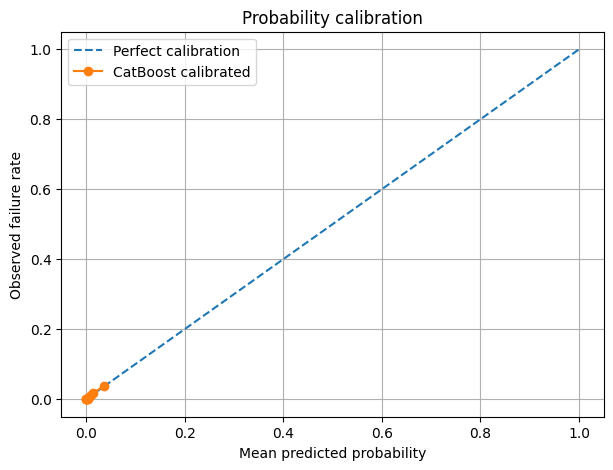

In [11]:
# Calibration plot

table = calibration_table(
    test[TARGET].values,
    cat_p_cal,
)

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.plot(
    table["mean_pred"],
    table["actual"],
    marker="o",
    label="CatBoost calibrated",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed failure rate")
plt.title("Probability calibration")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Model comparison on the untouched test set

results = []

def collect(name, y, p):
    results.append({
        "model": name,
        "PR-AUC": average_precision_score(y, p),
        "ROC-AUC": roc_auc_score(y, p),
        "Brier": brier_score_loss(y, p),
    })

y_test = test[TARGET].values

collect("Logistic Regression", y_test, lr_p_test)
collect("CatBoost raw", y_test, cat_p_test)
collect("XGBoost", y_test, xgb_p_test)
collect("CatBoost calibrated", y_test, cat_p_cal)

pd.DataFrame(results)


,model,PR-AUC,ROC-AUC,Brier
0,Logistic Regression,0.032628,0.787244,0.190505
1,CatBoost raw,0.072676,0.826575,0.041497
2,XGBoost,0.037857,0.777317,0.027808
3,CatBoost calibrated,0.063533,0.825412,0.007061


In [ ]:
# Save the trained model and metadata

os.makedirs("models", exist_ok=True)

cat_model.save_model(
    "models/first_attempt_failure_catboost.cbm"
)

joblib.dump(
    iso_model,
    "models/first_attempt_failure_isotonic.joblib"
)

joblib.dump(
    {
        "features": feature_cols,
        "categorical_features": cat_cols,
        "drop_position": DROP_POSITION, packages
high service time
tight time 
        "drop_location": DROP_LOCATION,
    },
    "models/first_attempt_failure_metadata.joblib",
)

print("Saved:")
print(" - models/first_attempt_failure_catboost.cbm")
print(" - models/first_attempt_failure_isotonic.joblib")
print(" - models/first_attempt_failure_metadata.joblib")


Saved:
 - models/first_attempt_failure_catboost.cbm
 - models/first_attempt_failure_isotonic.joblib
 - models/first_attempt_failure_metadata.joblib


In [35]:
dates = pd.to_datetime(df["date"]).drop_duplicates().sort_values()

if len(dates) < 3:
    raise ValueError(
        f"Need at least 3 unique dates to split into 2 days + 1 day. Found: {len(dates)}"
    )

first_two_dates = dates.iloc[:len(dates)-1]
last_day = dates.iloc[-1]

first_two_dates_str = [d.strftime("%Y-%m-%d") for d in first_two_dates]
last_day_str = last_day.strftime("%Y-%m-%d")

two_days_df = df[
    df["date"].dt.strftime("%Y-%m-%d").isin(first_two_dates_str)
].copy()

last_day_df = df[
    df["date"].dt.strftime("%Y-%m-%d") == last_day_str
].copy()

two_days_file = f"first_two_days_{first_two_dates_str[0]}_to_{first_two_dates_str[-1]}.csv"
last_day_file = f"last_day_{last_day_str}.csv"

two_days_df.to_csv(two_days_file, index=False)
last_day_df.to_csv(last_day_file, index=False)

print(f"Saved first 2 days to: {two_days_file}")
print(f"Saved last day to: {last_day_file}")
print(f"Rows in first 2 days: {len(two_days_df)}")
print(f"Rows in last day: {len(last_day_df)}")

Saved first 2 days to: first_two_days_2018-07-19_to_2018-08-25.csv
Saved last day to: last_day_2018-08-26.csv
Rows in first 2 days: 891546
Rows in last day: 6869
